# **Kaggle Competition 2 Retina Prediction**

**Importing important libraries and packages**

In [104]:
## Importing libraries and packages 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  
import pickle

**Loading training pickle data**

In [105]:
# Load the training and testing pickle file
train_path = r"C:\Users\Dell\OneDrive\Desktop\UdeM Graduate\Foundations of ML\Competition_2\train_data.pkl"
test_path = r"C:\Users\Dell\OneDrive\Desktop\UdeM Graduate\Foundations of ML\Competition_2\test_data.pkl"

# Opening Training path 
with open (train_path, 'rb') as f:
    train_data = pickle.load(f)

with open (test_path, 'rb') as t:
    test_data = pickle.load(t)

# Access images and labels
images_train = train_data['images']
labels_train = train_data ['labels']

images_test = test_data['images']

In [106]:
## Exploring shape of the data 
print("This is the shape of the images training data: ", images_train.shape)
print("This is the shape of the label training data", labels_train.shape)
print("This is the shape of the images test data: ", images_test.shape)

## Exploring data type 
print("This is the data type of the image training: ", images_train.dtype)
print("This is the number of unique value for labels training: ", np.unique(labels_train))
print("This is the data type of the image test: ", images_test.dtype)


This is the shape of the images training data:  (1080, 28, 28, 3)
This is the shape of the label training data (1080, 1)
This is the shape of the images test data:  (400, 28, 28, 3)
This is the data type of the image training:  uint8
This is the number of unique value for labels training:  [0 1 2 3 4]
This is the data type of the image test:  uint8


**Visualizing Data**

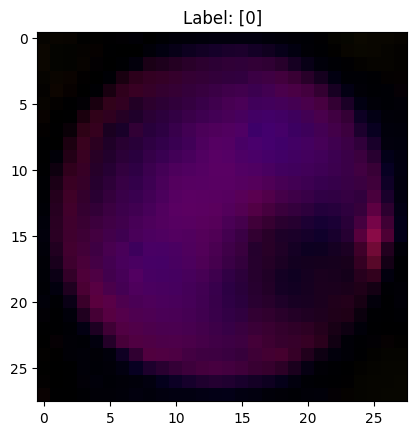

In [107]:
plt.imshow(images_train[0], cmap="gray")
plt.title(f"Label: {labels_train[0]}")
plt.show()

In [108]:
## Normalizing pixel values 
images_train_norm = images_train/255.0
images_test_norm = images_test/255.0

**Inspecting Pixel Statistics**

In [109]:
print(" The minimum pixel for training: ", images_train_norm.min())
print(" The maximum pixel for training: ", images_train_norm.max())
print(" The Mean pixel for training: ", images_train_norm.mean())
print(" The standard deviation for training: ", images_train_norm.std())

print(" The minimum pixel for test: ", images_test_norm.min())
print(" The maximum pixel for test: ", images_test_norm.max())
print(" The Mean pixel for test: ", images_test_norm.mean())
print(" The standard deviation for test: ", images_test_norm.std())


 The minimum pixel for training:  0.0
 The maximum pixel for training:  1.0
 The Mean pixel for training:  0.148014221120547
 The standard deviation for training:  0.1785871709035668
 The minimum pixel for test:  0.0
 The maximum pixel for test:  1.0
 The Mean pixel for test:  0.14282375450180074
 The standard deviation for test:  0.1726058264263377


In [110]:
per_image_train_means = images_train_norm.mean(axis=(1,2,3))
per_image_test_means = images_test_norm.mean(axis=(1,2,3))
print("Image mean min for training:", per_image_train_means.min())
print("Image mean max for training:", per_image_train_means.max())
print("Image mean min for testing:", per_image_test_means.min())
print("Image mean max for testing:", per_image_test_means.max())

Image mean min for training: 0.03572428971588635
Image mean max for training: 0.32874983326664
Image mean min for testing: 0.019034280378818193
Image mean max for testing: 0.27463652127517674


In [111]:
unique, counts = np.unique(labels_train, return_counts=True)
print("Class distribution:")
for u, c in zip(unique, counts):
    print(f"Label {u}: {c} samples")

Class distribution:
Label 0: 486 samples
Label 1: 128 samples
Label 2: 206 samples
Label 3: 194 samples
Label 4: 66 samples


In [112]:
print("The number of missing values in the images training dataset: ", np.isnan(images_train_norm).sum())
print("The number of missing values in the images testing dataset: ", np.isnan(images_test_norm).sum())


The number of missing values in the images training dataset:  0
The number of missing values in the images testing dataset:  0


**Identify low-variance images** 

In [113]:
# Removing low variance images that are below a certain threshold 
var = images_train_norm.var(axis=(1,2,3))
low_var_thresh = np.percentile(var, 1)
mask_var = var > low_var_thresh


**Removing Outliers**

In [115]:
# Removing outliers that are key for Logistic Regression and KNN
pixel_sums = images_train_norm.sum(axis=(1,2,3))

# Calculating lower and higher percentiles 
lowp = np.percentile(pixel_sums, 1)
highp = np.percentile(pixel_sums, 99)

# mask to help remove outliers 
mask_outlier = (pixel_sums > lowp) & (pixel_sums < highp)

# Combined Mask 
combined_mask = mask_var & mask_outlier

# Plotting images 
images_train_clean = images_train_norm[combined_mask]
labels_train_clean = labels_train[combined_mask]

# Seeing how much was removed after outlier and variance removal 
print("Original count:", len(images_train_norm))
print("After cleaning:", len(images_train_clean))
print("Removed:", len(images_train_norm) - len(images_train_clean))

Original count: 1080
After cleaning: 1055
Removed: 25


**Reshaping Image Data to be flattened**

In [116]:
X_train = images_train_clean.reshape(images_train_clean.shape[0], -1)
y_train = labels_train_clean.reshape(-1)
print("Training shape information: ", X_train.shape, y_train.shape)

X_test = images_test_norm.reshape(images_test_norm.shape[0], -1)
print("Test shape information: ", X_test.shape)

Training shape information:  (1055, 2352) (1055,)
Test shape information:  (400, 2352)


**Correlation between Pixels and Labels**

In [117]:
# Converting to Data Frame to make correlation analysis easier 
df_corr = pd.DataFrame(X_train)
df_corr['label'] = y_train
# Excluding Label self correlation here 
corr = df_corr.corr()['label'][:-1]
# Viewing the top correlated pixels
print(corr.abs().sort_values(ascending=False).head(20))

1215    0.411609
1299    0.411414
2321    0.411095
2318    0.406765
2003    0.403439
1296    0.398559
1218    0.398348
2303    0.397478
2208    0.397257
1007    0.397188
1091    0.396759
1511    0.395852
1427    0.395337
1841    0.395241
1343    0.394789
2300    0.394625
1212    0.394484
2315    0.394419
752     0.392991
2312    0.391802
Name: label, dtype: float64


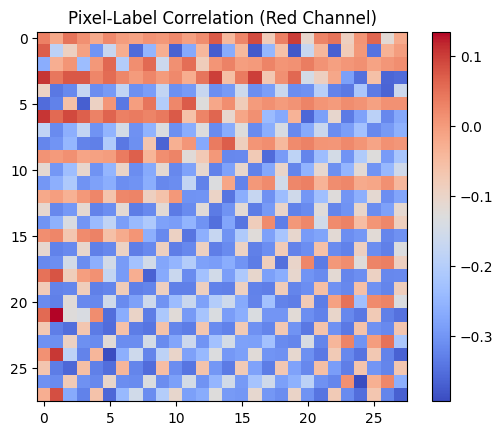

In [118]:
corr_r = corr[:784].values.reshape(28, 28)
corr_g = corr[784:2*784].values.reshape(28, 28)
corr_b = corr[2*784:].values.reshape(28, 28)

plt.imshow(corr_r, cmap="coolwarm")
plt.colorbar()
plt.title("Pixel-Label Correlation (Red Channel)")
plt.show()

In [119]:
## Removing unnecessary features 
threshold = 0.01 
# Ensures all correlation is greater than threshold
key_features = corr.abs() > threshold
X_train_streamlined = X_train[:, key_features.values]
X_test_streamlined = X_test[:, key_features.values]

## Determining Shapes of streamlined data set 
print("Orginal features shaped: ", X_train.shape[1])
print("Reduced number of features: ", X_train_streamlined.shape[1])

Orginal features shaped:  2352
Reduced number of features:  2252


**Train/Test Split**

In [120]:
def train_valid_split(X, y, ratio=0.2, seed=0):
    np.random.seed(seed)
    indx = np.random.permutation(len(X))
    split = int(len(X)*(1-ratio))
    return X[indx[:split]], X[indx[split:]], y[indx[:split]], y[indx[split:]]

X_tr, X_val, y_tr, y_val = train_valid_split(X_train_streamlined, y_train)
print("\n These are the features for X_trained here: ", X_tr)
print("\n These are the labels for y_trained here: ", y_tr)




 These are the features for X_trained here:  [[0.21568627 0.05098039 0.04705882 ... 0.         0.00392157 0.00392157]
 [0.03137255 0.00784314 0.01568627 ... 0.00784314 0.01568627 0.01568627]
 [0.00784314 0.         0.         ... 0.01568627 0.01568627 0.01568627]
 ...
 [0.07058824 0.0627451  0.         ... 0.00392157 0.01568627 0.01176471]
 [0.00392157 0.00392157 0.         ... 0.05098039 0.06666667 0.07058824]
 [0.01568627 0.01176471 0.         ... 0.         0.         0.        ]]

 These are the labels for y_trained here:  [3 0 0 2 0 0 0 1 2 3 0 0 0 0 1 0 0 0 2 1 3 0 2 0 3 2 0 1 0 1 0 2 3 1 0 0 0
 3 0 0 2 0 1 2 4 0 1 0 4 0 0 0 2 0 3 4 3 3 1 1 2 2 2 1 0 4 0 0 2 0 0 0 4 3
 3 3 0 0 3 0 1 2 2 4 0 0 2 3 4 0 0 3 1 2 2 0 3 0 0 0 4 0 0 3 2 2 2 4 0 2 1
 0 3 1 0 1 2 0 0 0 0 0 2 0 0 0 0 0 0 0 2 4 0 0 0 3 0 0 2 2 0 3 3 2 0 2 3 0
 0 0 0 2 2 1 0 2 2 0 0 1 0 0 1 3 0 0 0 0 0 2 0 3 0 0 1 3 0 2 2 3 0 0 0 2 3
 0 0 1 2 0 0 0 0 0 2 0 0 0 0 0 0 0 0 2 4 0 0 2 3 0 4 2 0 3 1 1 0 0 1 0 0 1
 0 3 0 0 3 0 2 0

**Defining KNN Model Pre November 30th**

In [164]:
import numpy as np

# ------------------------------------------
# L2 Normalization (CRITICAL for cosine KNN)
# ------------------------------------------
def l2_normalize(X):
    norms = np.linalg.norm(X, axis=1, keepdims=True) + 1e-8
    return X / norms

X_tr_norm = l2_normalize(X_tr)
X_val_norm = l2_normalize(X_val)


# ------------------------------------------
# Improved KNN: Cosine + Weighted Voting
# ------------------------------------------
def knn_predict(X_train, y_train, X_test, k):
    preds = []
    K = len(np.unique(y_train))

    for x in X_test:

        # cosine similarity (dot product of normalized vectors)
        sims = X_train @ x

        # choose top-k most similar samples
        idx = np.argsort(-sims)[:k]
        neighbor_labels = y_train[idx]
        weights = sims[idx] + 1e-8

        # weighted class vote
        vote = np.zeros(K)
        for lbl, w in zip(neighbor_labels, weights):
            vote[lbl] += w

        preds.append(np.argmax(vote))

    return np.array(preds)


# ------------------------------------------
# Evaluation
# ------------------------------------------
for k in [3, 5, 7, 9, 11, 13, 15]:
    y_pred_knn = knn_predict(X_tr_norm, y_tr, X_val_norm, k)
    acc = np.mean(y_pred_knn == y_val)
    print(f"k={k}, accuracy={acc:.4f}")


y_pred_test_knn = knn_predict(X_train_streamlined, y_train, X_test_streamlined, k=9)
df_sub = pd.DataFrame({
    "ID": np.arange(1, len(y_pred_test_knn) + 1),
    "Label": y_pred_test_knn
})

df_sub.to_csv("KNN_submission.csv", index=False)
print("KNN Saved submission.csv")





    


k=3, accuracy=0.4976
k=5, accuracy=0.5166
k=7, accuracy=0.5166
k=9, accuracy=0.5213
k=11, accuracy=0.5213
k=13, accuracy=0.5024
k=15, accuracy=0.4834
KNN Saved submission.csv


**Defining Logistic Regression Model**

In [166]:
import numpy as np

# ----------------------------------------
# Standardization (CRITICAL)
# ----------------------------------------
mu = X_tr.mean(axis=0, keepdims=True)
sigma = X_tr.std(axis=0, keepdims=True) + 1e-8

X_tr_std = (X_tr - mu) / sigma
X_val_std = (X_val - mu) / sigma

# ----------------------------------------
# Class weights (correct inverse frequency)
# ----------------------------------------
counts = np.bincount(y_tr)
freq = counts / len(y_tr)
inv = 1 / freq
class_weights = inv / inv.mean()

cw = {i: class_weights[i] for i in range(len(class_weights))}
print("Class weights:", cw)

# ----------------------------------------
# Softmax + one-hot
# ----------------------------------------
def lr_softmax(z):
    e = np.exp(z - np.max(z, axis=1, keepdims=True))
    return e / np.sum(e, axis=1, keepdims=True)

def one_hot(y, K):
    out = np.zeros((len(y), K))
    out[np.arange(len(y)), y] = 1
    return out

# ----------------------------------------
# Logistic Regression Training
# ----------------------------------------
def logistic_regression_train(X, y, class_weights, lr=0.01, reg=1e-4, epochs=6000):
    N, D = X.shape
    K = len(np.unique(y))

    W = np.zeros((D, K))
    b = np.zeros((1, K))

    y_onehot = one_hot(y, K)
    sample_weights = np.array([class_weights[c] for c in y])

    for epoch in range(epochs):

        logits = X @ W + b
        probs = lr_softmax(logits)

        weighted_error = (probs - y_onehot) * sample_weights[:, None]

        dW = (X.T @ weighted_error) / N + reg * W
        db = np.sum(weighted_error, axis=0, keepdims=True) / N

        W -= lr * dW
        b -= lr * db

        if epoch % 500 == 0:
            loss = -np.mean(sample_weights * np.log(probs[np.arange(N), y] + 1e-9))
            print(f"Epoch {epoch}, loss={loss:.4f}")

    return W, b

def logistic_regression_predict(X, W, b):
    return np.argmax(lr_softmax(X @ W + b), axis=1)

# ----------------------------------------
# Train
# ----------------------------------------
W, b = logistic_regression_train(
    X_tr_std, y_tr,
    class_weights=cw,
    lr=0.01,
    reg=1e-4,
    epochs=6000
)

# ----------------------------------------
# Evaluate
# ----------------------------------------
y_pred_lr = logistic_regression_predict(X_val_std, W, b)
acc_lr = np.mean(y_pred_lr == y_val)
print("Improved Logistic Regression accuracy:", acc_lr)

y_pred_test_lr = logistic_regression_predict(X_test_streamlined, W, b)
df_sub = pd.DataFrame({
    "ID": np.arange(1, len(y_pred_test_lr) + 1),
    "Label": y_pred_test_lr
})

df_sub.to_csv("LR_submission.csv", index=False)
print("Logistic Regression saved submission.csv")



Class weights: {0: np.float64(0.30386727745033154), 1: np.float64(1.1462716109760032), 2: np.float64(0.7469253723133956), 3: np.float64(0.7718228847238422), 4: np.float64(2.0311128545364268)}
Epoch 0, loss=1.1039
Epoch 500, loss=0.6470
Epoch 1000, loss=0.5421
Epoch 1500, loss=0.4754
Epoch 2000, loss=0.4270
Epoch 2500, loss=0.3896
Epoch 3000, loss=0.3594
Epoch 3500, loss=0.3343
Epoch 4000, loss=0.3130
Epoch 4500, loss=0.2945
Epoch 5000, loss=0.2782
Epoch 5500, loss=0.2638
Improved Logistic Regression accuracy: 0.46919431279620855
Logistic Regression saved submission.csv


**Random Forest Model**

In [167]:
import numpy as np

# ---------------------------------------------
# GINI impurity
# ---------------------------------------------
def gini(y):
    if len(y) == 0:
        return 0
    classes, counts = np.unique(y, return_counts=True)
    p = counts / len(y)
    return 1 - np.sum(p ** 2)


# ---------------------------------------------
# Best split finder for 1 feature
# ---------------------------------------------
def best_split_feature(X_col, y):
    idx = np.argsort(X_col)
    X_sorted = X_col[idx]
    y_sorted = y[idx]

    n = len(y)
    if n <= 1:
        return 1e9, None

    best_gini = 1e9
    best_thresh = None

    left_counts = {}
    right_counts = dict(zip(*np.unique(y_sorted, return_counts=True)))

    left_n = 0
    right_n = n

    for i in range(1, n):
        cls = y_sorted[i-1]
        left_counts[cls] = left_counts.get(cls, 0) + 1
        right_counts[cls] -= 1
        left_n += 1
        right_n -= 1

        if right_n == 0:
            break

        g_left = 1 - sum((c/left_n)**2 for c in left_counts.values())
        g_right = 1 - sum((c/right_n)**2 for c in right_counts.values())
        g = (left_n/n)*g_left + (right_n/n)*g_right

        if g < best_gini:
            best_gini = g
            best_thresh = (X_sorted[i] + X_sorted[i-1]) / 2

    return best_gini, best_thresh


# ---------------------------------------------
# Decision Tree (axis-aligned, numpy-only)
# ---------------------------------------------
class DecisionTree:
    def __init__(self, max_depth=6, min_samples=20, feature_subsample=200):
        self.max_depth = max_depth
        self.min_samples = min_samples
        self.feature_subsample = feature_subsample
        self.tree = None

    def build(self, X, y, depth):
        n, d = X.shape

        # ---- FIX #1: empty samples check ----
        if n == 0:
            return ("leaf", 0)

        # normal leaf conditions
        if depth >= self.max_depth or n < self.min_samples or len(set(y)) == 1:
            return ("leaf", np.bincount(y).argmax())

        # feature subsampling (handle d < feature_subsample)
        fs = min(self.feature_subsample, d)
        feat_idx = np.random.choice(d, fs, replace=False)

        best_f, best_thresh, best_gini = None, None, 1e9

        for f in feat_idx:
            g, t = best_split_feature(X[:, f], y)
            if t is not None and g < best_gini:
                best_gini = g
                best_f = f
                best_thresh = t

        # ---- FIX #2: failed split → leaf ----
        if best_f is None or best_thresh is None:
            return ("leaf", np.bincount(y).argmax())

        left_mask = X[:, best_f] < best_thresh
        right_mask = ~left_mask

        # ---- FIX #3: avoid empty left/right branches ----
        if left_mask.sum() == 0 or right_mask.sum() == 0:
            return ("leaf", np.bincount(y).argmax())

        return (
            "node",
            best_f,
            best_thresh,
            self.build(X[left_mask], y[left_mask], depth+1),
            self.build(X[right_mask], y[right_mask], depth+1)
        )

    def fit(self, X, y):
        self.tree = self.build(X, y, 0)

    def predict_one(self, x, node):
        if node[0] == "leaf":
            return node[1]
        _, f, thresh, left, right = node
        return self.predict_one(x, left if x[f] < thresh else right)

    def predict(self, X):
        return np.array([self.predict_one(x, self.tree) for x in X])


# ---------------------------------------------
# Random Forest
# ---------------------------------------------
class RandomForest:
    def __init__(self, n_trees=25, max_depth=6, min_samples=20, feature_subsample=200):
        self.n_trees = n_trees
        self.trees = [
            DecisionTree(max_depth, min_samples, feature_subsample)
            for _ in range(n_trees)
        ]

    def fit(self, X, y):
        n = len(X)
        for tree in self.trees:
            idx = np.random.choice(n, n, replace=True)
            tree.fit(X[idx], y[idx])

    def predict(self, X):
        preds = np.array([tree.predict(X) for tree in self.trees])
        final = np.apply_along_axis(lambda x: np.bincount(x).argmax(), 0, preds)
        return final


# ---------------------------------------------
# Train + Evaluate
# ---------------------------------------------
rf = RandomForest(
    n_trees=100,
    max_depth=10,
    min_samples=15,
    feature_subsample=150
)

rf.fit(X_tr, y_tr)
pred_val = rf.predict(X_val)
acc_rf = np.mean(pred_val == y_val)

print("Random Forest validation accuracy:", acc_rf)


y_pred_test_rf = rf.predict(X_test_streamlined)
df_sub = pd.DataFrame({
    "ID": np.arange(1, len(y_pred_test_rf) + 1),
    "Label": y_pred_test_rf
})

df_sub.to_csv("RF_submission.csv", index=False)
print("RF saved submission.csv")



Random Forest validation accuracy: 0.5260663507109005
RF saved submission.csv


**MLP**

In [168]:
import numpy as np

# =========================================================
# Standardization (CRITICAL for neural networks)
# =========================================================
mu = X_tr.mean(axis=0, keepdims=True)
std = X_tr.std(axis=0, keepdims=True) + 1e-8

X_tr_std = (X_tr - mu) / std
X_val_std = (X_val - mu) / std


# =========================================================
# Utils
# =========================================================
def softmax(z):
    e = np.exp(z - np.max(z, axis=1, keepdims=True))
    return e / (np.sum(e, axis=1, keepdims=True) + 1e-9)

def one_hot(y, K):
    out = np.zeros((len(y), K))
    out[np.arange(len(y)), y] = 1
    return out


# =========================================================
# IMPROVED MLP with:
# - Xavier initialization
# - Dropout
# - L2 regularization (weight decay)
# - Larger hidden layer (256)
# - Higher LR (0.002)
# =========================================================
class MLP:
    def __init__(self, input_dim, hidden_dim, output_dim, lr=0.002, reg=1e-4, dropout=0.2):
        self.lr = lr
        self.reg = reg
        self.dropout = dropout

        # Xavier init
        self.W1 = np.random.randn(input_dim, hidden_dim) / np.sqrt(input_dim)
        self.b1 = np.zeros((1, hidden_dim))
        self.W2 = np.random.randn(hidden_dim, output_dim) / np.sqrt(hidden_dim)
        self.b2 = np.zeros((1, output_dim))

    def relu(self, x):
        return np.maximum(0, x)

    def train(self, X, y, epochs=200, batch_size=128):
        N, D = X.shape
        K = len(np.unique(y))
        Y = one_hot(y, K)

        for epoch in range(epochs):
            # Random shuffle
            perm = np.random.permutation(N)
            X = X[perm]
            Y = Y[perm]

            for i in range(0, N, batch_size):
                xb = X[i:i + batch_size]
                yb = Y[i:i + batch_size]

                # --------------------------
                # Forward pass
                # --------------------------
                h = xb @ self.W1 + self.b1
                h_relu = self.relu(h)

                # Dropout mask
                mask = (np.random.rand(*h_relu.shape) > self.dropout).astype(float)
                h_drop = h_relu * mask / (1 - self.dropout)

                scores = h_drop @ self.W2 + self.b2
                probs = softmax(scores)

                # --------------------------
                # Backprop
                # --------------------------
                dscores = (probs - yb) / len(xb)
                dW2 = h_drop.T @ dscores + self.reg * self.W2
                db2 = np.sum(dscores, axis=0, keepdims=True)

                dh = dscores @ self.W2.T
                dh[h_relu <= 0] = 0  # relu gradient

                dW1 = xb.T @ dh + self.reg * self.W1
                db1 = np.sum(dh, axis=0, keepdims=True)

                # --------------------------
                # Update
                # --------------------------
                self.W1 -= self.lr * dW1
                self.b1 -= self.lr * db1
                self.W2 -= self.lr * dW2
                self.b2 -= self.lr * db2

            # Progress print
            if epoch % 20 == 0:
                loss = -np.mean(np.log(probs[np.arange(len(yb)), np.argmax(yb, axis=1)] + 1e-9))
                print(f"Epoch {epoch} loss={loss:.4f}")

    def predict(self, X):
        h = X @ self.W1 + self.b1
        h_relu = self.relu(h)
        scores = h_relu @ self.W2 + self.b2
        probs = softmax(scores)
        return np.argmax(probs, axis=1)
    
    import numpy as np

# ---------------------------------------------------------
# PARAMETERS TO TEST
# ---------------------------------------------------------
learning_rates = [0.001, 0.0015]
batch_sizes = [100, 140, 170, 200]
epoch_values = [120, 160, 200]

best_acc = 0
best_params = None

print("\n====== STARTING HYPERPARAMETER TUNING ======\n")

for lr in learning_rates:
    for bs in batch_sizes:
        for ep in epoch_values:

            print(f"\n🔍 Testing: lr={lr}, batch={bs}, epochs={ep}")

            # create new model each time
            model = MLP(
                input_dim=X_tr.shape[1],
                hidden_dim=256,
                output_dim=5,
                lr=lr,
                reg=1e-4,
                dropout=0.2
            )

            model.train(X_tr_std, y_tr, epochs=ep, batch_size=bs)

            # evaluate
            y_pred = model.predict(X_val_std)
            acc = np.mean(y_pred == y_val)

            print(f"→ Accuracy = {acc:.4f}")

            if acc > best_acc:
                best_acc = acc
                best_params = (lr, bs, ep)

print("\n🎉 BEST RESULT:")
print("Learning Rate =", best_params[0])
print("Batch Size    =", best_params[1])
print("Epochs        =", best_params[2])
print("💛 Best Accuracy =", best_acc)

import pandas as pd

# =========================================================
# 1. Combine train + validation for final training
# =========================================================
X_full = np.vstack([X_tr, X_val])
y_full = np.hstack([y_tr, y_val])

# Standardize using ONLY training statistics
mu_full = X_full.mean(axis=0, keepdims=True)
std_full = X_full.std(axis=0, keepdims=True) + 1e-8

X_full_std = (X_full - mu_full) / std_full
X_test_std = (X_test - mu_full) / std_full


# =========================================================
# 2. Train FINAL model using best hyperparameters
# =========================================================
best_lr, best_bs, best_epochs = best_params

print("\n🚀 Training FINAL MLP for Kaggle submission...")
print(f"Using best params: LR={best_lr}, batch={best_bs}, epochs={best_epochs}")

final_model = MLP(
    input_dim=X_full.shape[1],
    hidden_dim=256,
    output_dim=5,
    lr=best_lr,
    reg=1e-4,
    dropout=0.2
)

final_model.train(X_full_std, y_full, epochs=best_epochs, batch_size=best_bs)

print("\n🎯 Final model training complete.")


# =========================================================
# 3. Predict on test set
# =========================================================
test_predictions = final_model.predict(X_test_std)

print("Test predictions generated.")


# =========================================================
# 4. Create submission file
# =========================================================
df_sub = pd.DataFrame({
    "Id": np.arange(len(test_predictions)),
    "Label": test_predictions
})

df_sub.to_csv("submission_mlp.csv", index=False)
print("\n📁 Saved submission_mlp.csv")
print(df_sub.head())



====== STARTING HYPERPARAMETER TUNING ======


🔍 Testing: lr=0.001, batch=100, epochs=120
Epoch 0 loss=1.7159
Epoch 20 loss=1.2710
Epoch 40 loss=1.2724
Epoch 60 loss=0.9943
Epoch 80 loss=1.0315
Epoch 100 loss=1.0930
→ Accuracy = 0.4882

🔍 Testing: lr=0.001, batch=100, epochs=160
Epoch 0 loss=1.4996
Epoch 20 loss=1.0928
Epoch 40 loss=1.0264
Epoch 60 loss=1.0624
Epoch 80 loss=1.1244
Epoch 100 loss=1.2252
Epoch 120 loss=1.2034
Epoch 140 loss=1.0530
→ Accuracy = 0.4834

🔍 Testing: lr=0.001, batch=100, epochs=200
Epoch 0 loss=1.5014
Epoch 20 loss=1.2254
Epoch 40 loss=1.2882
Epoch 60 loss=1.1022
Epoch 80 loss=1.1489
Epoch 100 loss=1.2431
Epoch 120 loss=1.0481
Epoch 140 loss=1.0356
Epoch 160 loss=1.0748
Epoch 180 loss=1.1793
→ Accuracy = 0.5118

🔍 Testing: lr=0.001, batch=140, epochs=120
Epoch 0 loss=1.2586
Epoch 20 loss=1.6625
Epoch 40 loss=1.3520
Epoch 60 loss=1.2735
Epoch 80 loss=1.5636
Epoch 100 loss=1.5633
→ Accuracy = 0.5118

🔍 Testing: lr=0.001, batch=140, epochs=160
Epoch 0 loss=1.89

ValueError: operands could not be broadcast together with shapes (400,2352) (1,2252) 

**SVM**

In [ ]:

import numpy as np

# ============================================================
# Multiclass SVM (OVR) implementation
# ============================================================

def svm_train_ovr(X, y, lr=0.0007, C=1.0, epochs=1500):
    N, D = X.shape
    K = len(np.unique(y))

    W = np.zeros((K, D))
    b = np.zeros(K)

    for cls in range(K):
        # Convert to binary classification
        y_bin = np.where(y == cls, 1, -1)

        w = np.zeros(D)
        bias = 0

        for epoch in range(epochs):
            scores = X @ w + bias
            margins = 1 - y_bin * scores

            # hinge loss indicator
            indicator = (margins > 0).astype(float)

            # gradients
            dw = w - C * (X * (indicator * y_bin)[:, None]).mean(axis=0)
            db = -C * (indicator * y_bin).mean()

            # update
            w -= lr * dw
            bias -= lr * db

            # print loss for class 0 only
            if cls == 0 and epoch % 400 == 0:
                loss = np.maximum(0, margins).mean() + 0.5 * np.sum(w * w)
                print(f"Class {cls} | Epoch {epoch}, Loss={loss:.4f}")

        W[cls] = w
        b[cls] = bias

    return W, b


def svm_predict_ovr(X, W, b):
    scores = X @ W.T + b
    return np.argmax(scores, axis=1)


learning_rates = [0.0004]
C_values = [1.0, 2.0]
epoch_values = [1200, 1800]

best_acc = 0
best_params = None
best_model = None

print("\n===== MULTICLASS SVM HYPERPARAMETER SEARCH =====")

for lr in learning_rates:
    for C in C_values:
        for ep in epoch_values:
            print(f"\nTesting: LR={lr}, C={C}, epochs={ep}")

            W_svm, b_svm = svm_train_ovr(
                X_tr_std, y_tr,
                lr=lr,
                C=C,
                epochs=ep
            )

            y_pred_svm = svm_predict_ovr(X_val_std, W_svm, b_svm)
            acc = np.mean(y_pred_svm == y_val)

            print(f"→ Validation Accuracy = {acc:.4f}")

            if acc > best_acc:
                best_acc = acc
                best_params = (lr, C, ep)
                best_model = (W_svm, b_svm)

print("\n🎉 BEST SVM RESULTS:")
print("Best LR =", best_params[0])
print("Best C =", best_params[1])
print("Best Epochs =", best_params[2])
print("Best Accuracy =", best_acc)



===== MULTICLASS SVM HYPERPARAMETER SEARCH =====

Testing: LR=0.0004, C=0.5, epochs=1200
Class 0 | Epoch 0, Loss=1.0000
Class 0 | Epoch 400, Loss=0.5790
Class 0 | Epoch 800, Loss=0.5542
→ Validation Accuracy = 0.4550

Testing: LR=0.0004, C=0.5, epochs=1800
Class 0 | Epoch 0, Loss=1.0000
Class 0 | Epoch 400, Loss=0.5790
Class 0 | Epoch 800, Loss=0.5542
Class 0 | Epoch 1200, Loss=0.5422
Class 0 | Epoch 1600, Loss=0.5344
→ Validation Accuracy = 0.4597

Testing: LR=0.0004, C=1.0, epochs=1200
Class 0 | Epoch 0, Loss=1.0000
Class 0 | Epoch 400, Loss=0.5508
Class 0 | Epoch 800, Loss=0.5288
→ Validation Accuracy = 0.4739

Testing: LR=0.0004, C=1.0, epochs=1800
Class 0 | Epoch 0, Loss=1.0000
Class 0 | Epoch 400, Loss=0.5508
Class 0 | Epoch 800, Loss=0.5288
Class 0 | Epoch 1200, Loss=0.5180
Class 0 | Epoch 1600, Loss=0.5111
→ Validation Accuracy = 0.5118

Testing: LR=0.0004, C=2.0, epochs=1200
Class 0 | Epoch 0, Loss=1.0000
Class 0 | Epoch 400, Loss=0.5264
Class 0 | Epoch 800, Loss=0.5075
→ Val

**Generating Kaggle Submission File**

In [ ]:
y_pred_knn = knn_predict(X_train_streamlined, y_train, X_test_streamlined, k=5)
df_sub = pd.DataFrame({
    "ID": np.arange(1, len(y_pred_knn) + 1),
    "Label": y_pred_knn
})

df_sub.to_csv("submission.csv", index=False)
print("Saved submission.csv")


Saved submission.csv
